Using device: cpu
DCGAN for CIFAR-10 Single Class Generation

Generator parameters: 3,575,360
Discriminator parameters: 2,759,424


100.0%


Successfully loaded 5000 samples from class 0

Dataset size: 5000 airplane images
Number of batches: 157

Starting Training...
--------------------------------------------------
[1/25][0/157] Loss_D: 1.3189 Loss_G: 2.5472 D(x): 0.5097 D(G(z)): 0.4445/0.0813
[1/25][25/157] Loss_D: 0.8906 Loss_G: 7.0550 D(x): 0.8521 D(G(z)): 0.4677/0.0010
[1/25][50/157] Loss_D: 1.3560 Loss_G: 4.6034 D(x): 0.7892 D(G(z)): 0.5702/0.0154
[1/25][75/157] Loss_D: 0.6556 Loss_G: 4.9806 D(x): 0.8338 D(G(z)): 0.3149/0.0112
[1/25][100/157] Loss_D: 0.6785 Loss_G: 5.8306 D(x): 0.8394 D(G(z)): 0.3360/0.0037
[1/25][125/157] Loss_D: 0.6928 Loss_G: 3.1221 D(x): 0.6871 D(G(z)): 0.2089/0.0575
[1/25][150/157] Loss_D: 1.3289 Loss_G: 3.5773 D(x): 0.6847 D(G(z)): 0.5488/0.0404
Epoch [1/25] Avg Loss_G: 4.1951, Avg Loss_D: 0.7832
[2/25][0/157] Loss_D: 1.1977 Loss_G: 2.6394 D(x): 0.7333 D(G(z)): 0.5079/0.0838
[2/25][25/157] Loss_D: 0.5484 Loss_G: 3.2975 D(x): 0.8790 D(G(z)): 0.2816/0.0446
[2/25][50/157] Loss_D: 0.4004 Loss_G: 3.

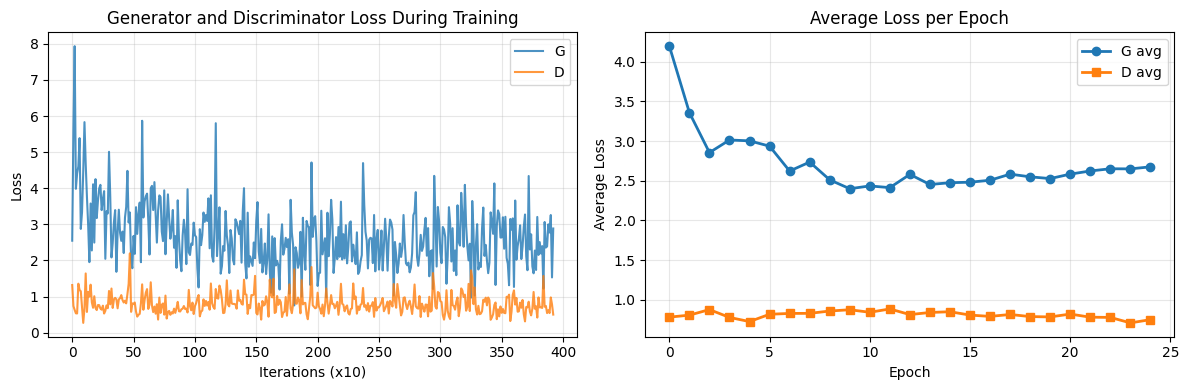

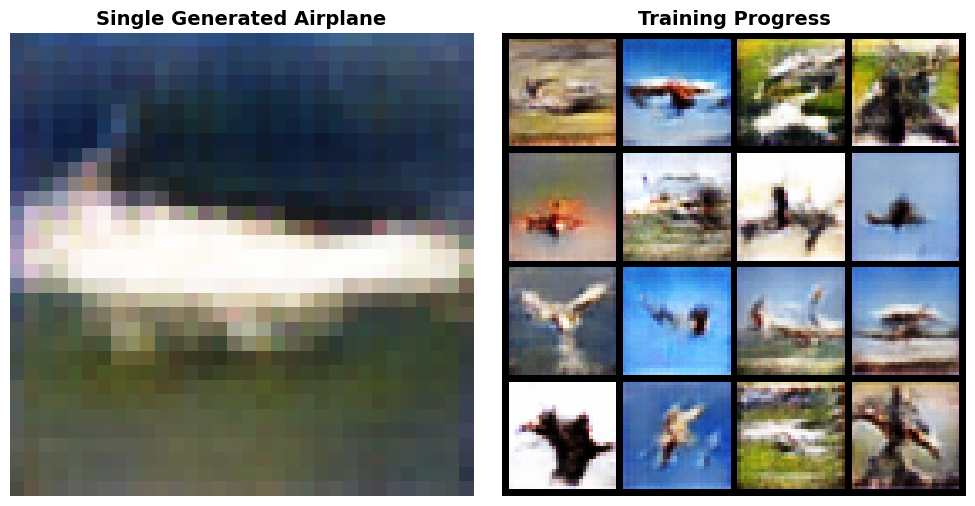

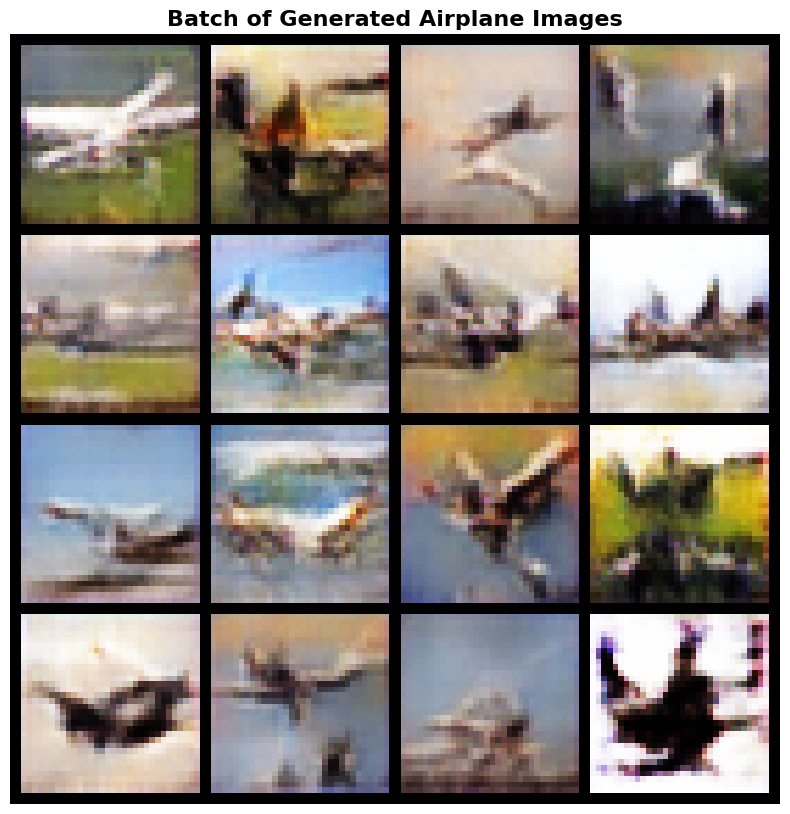


Demonstrating noise vector control...


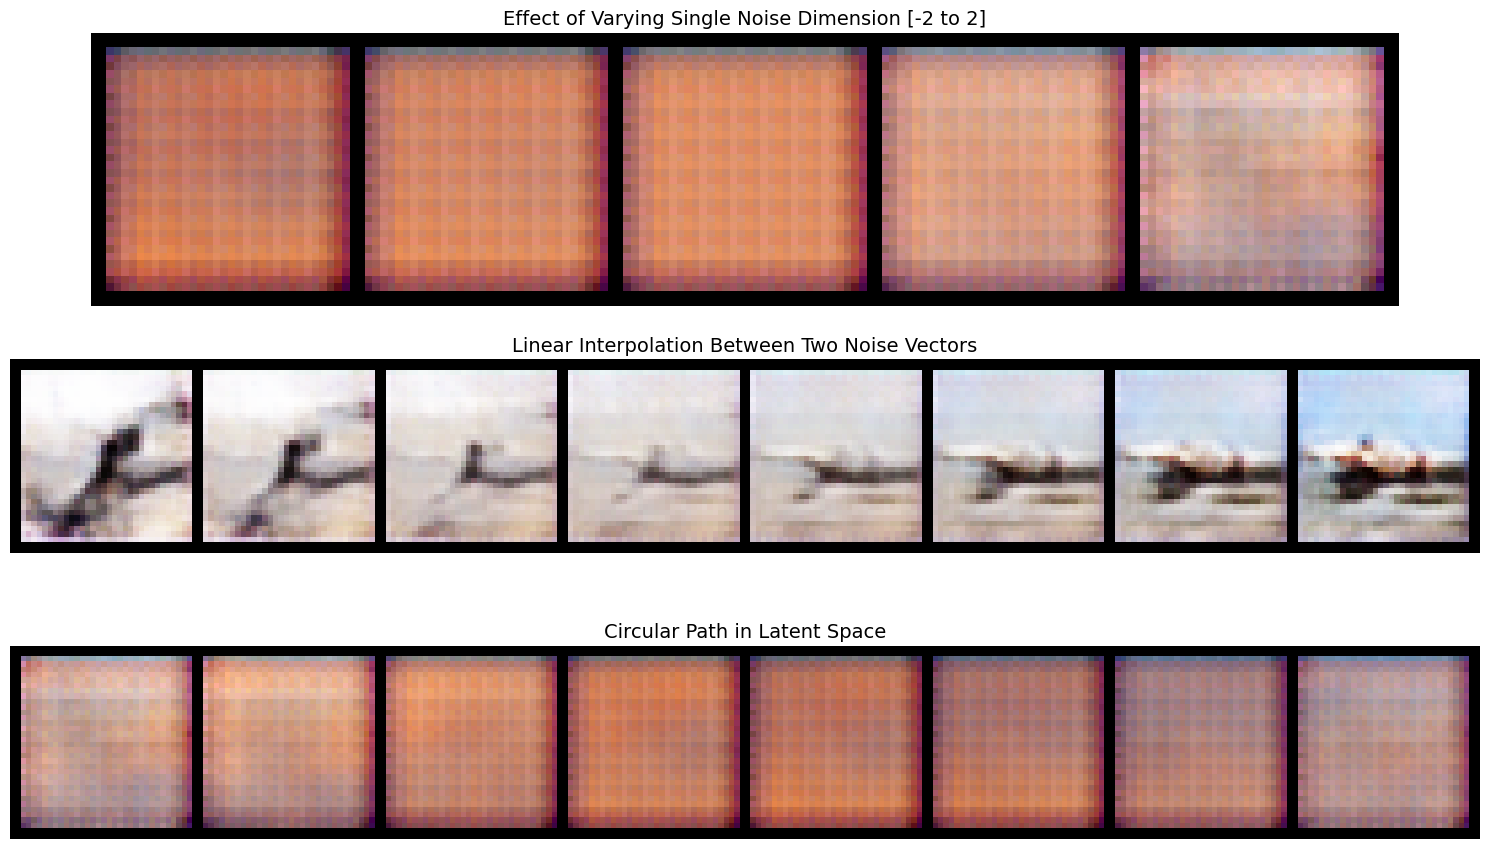

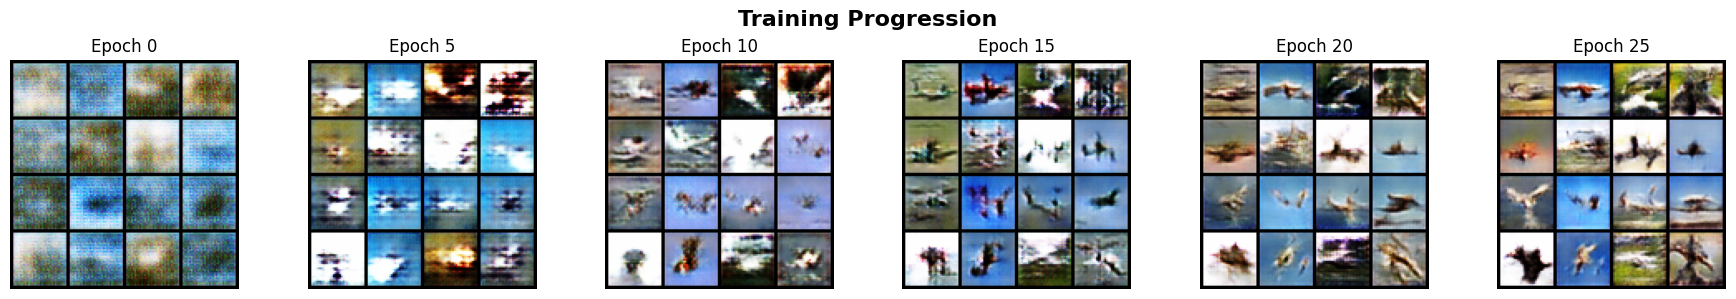


TRAINING COMPLETE!

Key Achievements:
✓ Generator uses Transposed Convolution layers (ConvTranspose2d)
✓ Discriminator uses standard Convolution layers (Conv2d)
✓ Trained on single CIFAR-10 class (airplanes) for focused generation
✓ Demonstrated noise vector control with multiple visualization methods
✓ Applied label smoothing for training stability

The model can now generate 32x32 airplane images from random noise!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import warnings
import os
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Hyperparameters - Adjusted for better stability
batch_size = 32  # Reduced for memory efficiency
image_size = 32
nc = 3  # Number of channels (RGB)
nz = 100  # Size of latent vector (noise)
ngf = 64  # Generator feature maps
ndf = 64  # Discriminator feature maps
num_epochs = 25  # Reduced for faster testing
lr = 0.0002
beta1 = 0.5

# Device configuration with better error handling
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cpu':
    print("WARNING: Training on CPU will be slow. GPU is recommended.")

# Generator Architecture with Transposed Convolutions
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input: nz x 1 x 1
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # State: (ngf*8) x 4 x 4
            
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State: (ngf*4) x 8 x 8
            
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State: (ngf*2) x 16 x 16
            
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State: ngf x 32 x 32
            
            nn.ConvTranspose2d(ngf, nc, 3, 1, 1, bias=False),
            nn.Tanh()
            # Output: nc x 32 x 32
        )
        
    def forward(self, input):
        return self.main(input)

# Discriminator Architecture with Convolutions
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: nc x 32 x 32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State: ndf x 16 x 16
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*2) x 8 x 8
            
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*4) x 4 x 4
            
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*8) x 2 x 2
            
            nn.Conv2d(ndf * 8, 1, 2, 1, 0, bias=False),
            nn.Sigmoid()
            # Output: 1 x 1 x 1
        )
        
    def forward(self, input):
        output = self.main(input)
        return output.view(-1, 1).squeeze(1)

# Custom weight initialization
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

# Load CIFAR-10 dataset with error handling
def get_single_class_dataset(class_id=0, data_root='./data'):
    """
    Load CIFAR-10 and filter for a single class
    Classes: 0=airplane, 1=automobile, 2=bird, 3=cat, 4=deer, 
             5=dog, 6=frog, 7=horse, 8=ship, 9=truck
    """
    # Create data directory if it doesn't exist
    os.makedirs(data_root, exist_ok=True)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    try:
        # Load full dataset
        full_dataset = torchvision.datasets.CIFAR10(
            root=data_root, 
            train=True, 
            download=True, 
            transform=transform
        )
        
        # Filter for single class
        indices = [i for i, (_, label) in enumerate(full_dataset) if label == class_id]
        
        if len(indices) == 0:
            raise ValueError(f"No samples found for class_id {class_id}")
            
        filtered_dataset = torch.utils.data.Subset(full_dataset, indices)
        
        print(f"Successfully loaded {len(indices)} samples from class {class_id}")
        return filtered_dataset
        
    except Exception as e:
        print(f"Error loading dataset: {e}")
        raise

# Improved training function with stability enhancements
def train_gan(generator, discriminator, dataloader, num_epochs=25):
    # Loss function
    criterion = nn.BCELoss()
    
    # Separate optimizers for G and D
    optimizerD = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizerG = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
    
    # Training metrics
    G_losses = []
    D_losses = []
    img_list = []
    
    # Fixed noise for consistent visualization
    fixed_noise = torch.randn(16, nz, 1, 1, device=device)
    
    # Labels for real and fake data
    real_label = 1.0
    fake_label = 0.0
    
    print("\nStarting Training...")
    print("-" * 50)
    
    for epoch in range(num_epochs):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        
        for i, data in enumerate(dataloader, 0):
            ############################
            # (1) Update Discriminator
            ############################
            discriminator.zero_grad()
            
            # Train with real batch
            real_batch = data[0].to(device)
            b_size = real_batch.size(0)
            
            # Create labels with small noise for stability
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
            label = label + torch.randn_like(label) * 0.05  # Label smoothing
            label = torch.clamp(label, 0.0, 1.0)
            
            output = discriminator(real_batch)
            errD_real = criterion(output, label)
            errD_real.backward()
            D_x = output.mean().item()
            
            # Train with fake batch
            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = generator(noise)
            label = torch.full((b_size,), fake_label, dtype=torch.float, device=device)
            label = label + torch.randn_like(label) * 0.05  # Label smoothing
            label = torch.clamp(label, 0.0, 1.0)
            
            output = discriminator(fake.detach())
            errD_fake = criterion(output, label)
            errD_fake.backward()
            D_G_z1 = output.mean().item()
            
            errD = errD_real + errD_fake
            optimizerD.step()
            
            ############################
            # (2) Update Generator
            ############################
            generator.zero_grad()
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
            
            output = discriminator(fake)
            errG = criterion(output, label)
            errG.backward()
            D_G_z2 = output.mean().item()
            
            optimizerG.step()
            
            # Save losses
            G_losses.append(errG.item())
            D_losses.append(errD.item())
            epoch_g_loss += errG.item()
            epoch_d_loss += errD.item()
            
            # Print progress
            if i % 25 == 0:
                print(f'[{epoch+1}/{num_epochs}][{i}/{len(dataloader)}] '
                      f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                      f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}')
        
        # Save generated images periodically
        if (epoch + 1) % 5 == 0 or epoch == 0:
            with torch.no_grad():
                fake = generator(fixed_noise)
                img_list.append(vutils.make_grid(fake.detach().cpu(), normalize=True, nrow=4))
        
        # Print epoch summary
        avg_g_loss = epoch_g_loss / len(dataloader)
        avg_d_loss = epoch_d_loss / len(dataloader)
        print(f'Epoch [{epoch+1}/{num_epochs}] Avg Loss_G: {avg_g_loss:.4f}, Avg Loss_D: {avg_d_loss:.4f}')
    
    print("-" * 50)
    print("Training Complete!")
    
    return G_losses, D_losses, img_list

# Enhanced noise control demonstration
def demonstrate_noise_control(generator, nz=100):
    """Demonstrate the effect of controlling noise vectors"""
    generator.eval()
    
    with torch.no_grad():
        # 1. Single dimension variation
        base_noise = torch.zeros(1, nz, 1, 1, device=device)
        variations = []
        
        for val in [-2, -1, 0, 1, 2]:
            modified_noise = base_noise.clone()
            modified_noise[0, 0, 0, 0] = val  # Modify first dimension
            variations.append(generator(modified_noise))
        
        # 2. Linear interpolation between two random points
        noise1 = torch.randn(1, nz, 1, 1, device=device)
        noise2 = torch.randn(1, nz, 1, 1, device=device)
        
        interpolations = []
        for alpha in np.linspace(0, 1, 8):
            interpolated = (1 - alpha) * noise1 + alpha * noise2
            interpolations.append(generator(interpolated))
        
        # 3. Circular interpolation (smooth loop)
        angles = np.linspace(0, 2*np.pi, 8, endpoint=False)
        circular = []
        for angle in angles:
            z = torch.zeros(1, nz, 1, 1, device=device)
            z[0, 0, 0, 0] = np.cos(angle) * 2
            z[0, 1, 0, 0] = np.sin(angle) * 2
            circular.append(generator(z))
    
    return variations, interpolations, circular

# Main execution function
def main():
    print("="*50)
    print("DCGAN for CIFAR-10 Single Class Generation")
    print("="*50)
    
    # Initialize models
    netG = Generator(nz, ngf, nc).to(device)
    netG.apply(weights_init)
    
    netD = Discriminator(nc, ndf).to(device)
    netD.apply(weights_init)
    
    # Print model summaries
    total_params_g = sum(p.numel() for p in netG.parameters())
    total_params_d = sum(p.numel() for p in netD.parameters())
    print(f"\nGenerator parameters: {total_params_g:,}")
    print(f"Discriminator parameters: {total_params_d:,}")
    
    # Load dataset (using airplanes - class 0)
    try:
        dataset = get_single_class_dataset(class_id=0)
        num_workers = 0 if device.type == 'cpu' else 2
        dataloader = DataLoader(
            dataset, 
            batch_size=batch_size, 
            shuffle=True, 
            num_workers=num_workers,
            pin_memory=(device.type == 'cuda')
        )
        
        print(f"\nDataset size: {len(dataset)} airplane images")
        print(f"Number of batches: {len(dataloader)}")
        
    except Exception as e:
        print(f"Failed to load dataset: {e}")
        return None, None
    
    # Train the GAN
    G_losses, D_losses, img_list = train_gan(netG, netD, dataloader, num_epochs)
    
    # Visualization
    print("\nGenerating visualizations...")
    
    # Plot training losses
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(G_losses[::10], label="G", alpha=0.8)  # Sample every 10th point for clarity
    plt.plot(D_losses[::10], label="D", alpha=0.8)
    plt.xlabel("Iterations (x10)")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot loss averages per epoch
    plt.subplot(1, 2, 2)
    epoch_size = len(dataloader)
    g_avg = [np.mean(G_losses[i:i+epoch_size]) for i in range(0, len(G_losses), epoch_size)]
    d_avg = [np.mean(D_losses[i:i+epoch_size]) for i in range(0, len(D_losses), epoch_size)]
    plt.title("Average Loss per Epoch")
    plt.plot(g_avg, 'o-', label="G avg", linewidth=2)
    plt.plot(d_avg, 's-', label="D avg", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Generate final images
    netG.eval()
    with torch.no_grad():
        # Generate single image
        single_noise = torch.randn(1, nz, 1, 1, device=device)
        single_image = netG(single_noise)
        
        # Generate batch
        batch_noise = torch.randn(16, nz, 1, 1, device=device)
        batch_images = netG(batch_noise)
    
    # Display single generated image
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Single image
    axes[0].set_title("Single Generated Airplane", fontsize=14, fontweight='bold')
    img = single_image.cpu().squeeze()
    img = (img + 1) / 2  # Denormalize
    img = torch.clamp(img, 0, 1)
    axes[0].imshow(img.permute(1, 2, 0))
    axes[0].axis('off')
    
    # Real sample for comparison (if available)
    axes[1].set_title("Training Progress", fontsize=14, fontweight='bold')
    if len(img_list) > 0:
        axes[1].imshow(np.transpose(img_list[-1], (1, 2, 0)))
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Display batch of generated images
    plt.figure(figsize=(10, 10))
    plt.title("Batch of Generated Airplane Images", fontsize=16, fontweight='bold')
    grid = vutils.make_grid(batch_images.cpu(), padding=2, normalize=True, nrow=4)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis('off')
    plt.show()
    
    # Demonstrate noise control
    print("\nDemonstrating noise vector control...")
    variations, interpolations, circular = demonstrate_noise_control(netG, nz)
    
    # Display noise control effects
    fig, axes = plt.subplots(3, 1, figsize=(15, 9))
    
    # Dimension variation
    axes[0].set_title("Effect of Varying Single Noise Dimension [-2 to 2]", fontsize=14)
    grid = vutils.make_grid(torch.cat(variations), nrow=5, normalize=True)
    axes[0].imshow(np.transpose(grid.cpu(), (1, 2, 0)))
    axes[0].axis('off')
    
    # Linear interpolation
    axes[1].set_title("Linear Interpolation Between Two Noise Vectors", fontsize=14)
    grid = vutils.make_grid(torch.cat(interpolations), nrow=8, normalize=True)
    axes[1].imshow(np.transpose(grid.cpu(), (1, 2, 0)))
    axes[1].axis('off')
    
    # Circular interpolation
    axes[2].set_title("Circular Path in Latent Space", fontsize=14)
    grid = vutils.make_grid(torch.cat(circular), nrow=8, normalize=True)
    axes[2].imshow(np.transpose(grid.cpu(), (1, 2, 0)))
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Training progression animation
    if len(img_list) > 1:
        fig, axes = plt.subplots(1, min(len(img_list), 6), figsize=(18, 3))
        fig.suptitle("Training Progression", fontsize=16, fontweight='bold')
        
        indices = np.linspace(0, len(img_list)-1, min(len(img_list), 6), dtype=int)
        for idx, ax_idx in enumerate(indices):
            if len(img_list) > 1:
                axes[idx].imshow(np.transpose(img_list[ax_idx], (1, 2, 0)))
                axes[idx].set_title(f"Epoch {ax_idx * 5}")
                axes[idx].axis('off')
            else:
                axes.imshow(np.transpose(img_list[ax_idx], (1, 2, 0)))
                axes.set_title(f"Epoch {ax_idx * 5}")
                axes.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return netG, netD

# Execute the training
if __name__ == "__main__":
    try:
        generator, discriminator = main()
        
        if generator is not None:
            print("\n" + "="*50)
            print("TRAINING COMPLETE!")
            print("="*50)
            print("\nKey Achievements:")
            print("✓ Generator uses Transposed Convolution layers (ConvTranspose2d)")
            print("✓ Discriminator uses standard Convolution layers (Conv2d)")
            print("✓ Trained on single CIFAR-10 class (airplanes) for focused generation")
            print("✓ Demonstrated noise vector control with multiple visualization methods")
            print("✓ Applied label smoothing for training stability")
            print("\nThe model can now generate 32x32 airplane images from random noise!")
            
    except Exception as e:
        print(f"\nAn error occurred: {e}")
        print("\nTroubleshooting tips:")
        print("1. Ensure PyTorch is installed: pip install torch torchvision")
        print("2. Check matplotlib is installed: pip install matplotlib")
        print("3. Verify numpy is installed: pip install numpy")
        print("4. If memory error, reduce batch_size (currently 32)")
        print("5. If CUDA error, the code will automatically fall back to CPU")